# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

My Answers:
1. The intuition is that regularization discourages the model from putting too much weight on any variable(s). A model with very large coefficients can fit the training data extremely closely, but that often means it is also fitting noise. By adding a penalty for large coefficients, we force the model to stay simpler and more stable.
2. Regularization lets us directly control the balance between fitting the data closely and keeping the model simple. With little or no penalty, the model has low bias because it can fit the training data very flexibly. As the penalty gets larger, the coefficients are shrunk toward zero, which increases bias but lowers variance.
3. The main difference is the type of penalty used. Ridge regression uses a squared penalty on coefficients, while LASSO uses an absolute value penalty. Ridge usually shrinks coefficients toward zero but rarely makes them exactly zero. LASSO can force some coefficients to become exactly zero. In practice, Ridge tends to keep all predictors in the model but with smaller coefficients, while LASSO tends to select only the most important predictors.
4. We usually standardize the predictors by converting them to z-scores, so each variable has mean zero and standard deviation one. Standardizing puts all variables on the same scale, so the penalty treats them fairly and the coefficient sizes become more comparable.
5. $\alpha$ is usually chosen using cross-validation. The value that gives the lowest average prediction error is typically selected. This works well because it chooses the amount of regularization based on out-of-sample performance rather than just how well the model fits the training data.
6. No, we usually do not include the penalty term. The reason is that cross-validation is meant to measure how well the model predicts new data, and prediction error depends on the difference between actual and predicted values, not on the size of the coefficients themselves. The penalty is part of the fitting procedure used to estimate the coefficients, but once the model is fit, we judge it based on predictive accuracy alone.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

cars = pd.read_csv("cars_hw.csv")
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [11]:
#Q1
current_year = 2026

cars["Age"] = current_year - cars["Make_Year"]

X = cars[["Mileage_Run", "Age"]]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
print(feature_names)

['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [14]:
#Q2

from sklearn.linear_model import LinearRegression
import pandas as pd

y = cars["Price"]

lr = LinearRegression()
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr.coef_
})

print(coef_df)
print("\nInteraction term:")
print(coef_df[coef_df["Feature"] == "Mileage_Run Age"])

             Feature   Coefficient
0        Mileage_Run  9.117748e+05
1                Age -2.481722e+05
2      Mileage_Run^2 -2.072926e+05
3    Mileage_Run Age -1.671212e+06
4              Age^2  3.505507e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  3.388195e+05
7  Mileage_Run Age^2  7.167816e+05
8              Age^3 -2.100379e+05

Interaction term:
           Feature   Coefficient
3  Mileage_Run Age -1.671212e+06


The interaction term between Mileage_Run and Age has a negative coefficient (-1.67 × 10⁶). This indicates that the combined effect of mileage and age on a car’s price is strongly negative.

In [15]:
#Q3
from sklearn.linear_model import LassoCV
import numpy as np

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X_scaled, y)

print("Optimal alpha:", lasso_cv.alpha_)

Optimal alpha: 88.58667904100822


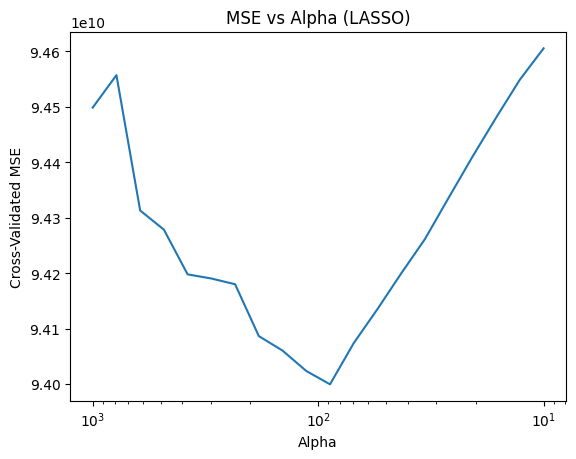

In [16]:
#Q4
import matplotlib.pyplot as plt

mse_mean = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure()
plt.plot(lasso_cv.alphas_, mse_mean)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("MSE vs Alpha (LASSO)")
plt.gca().invert_xaxis()  # optional: matches typical presentation
plt.show()

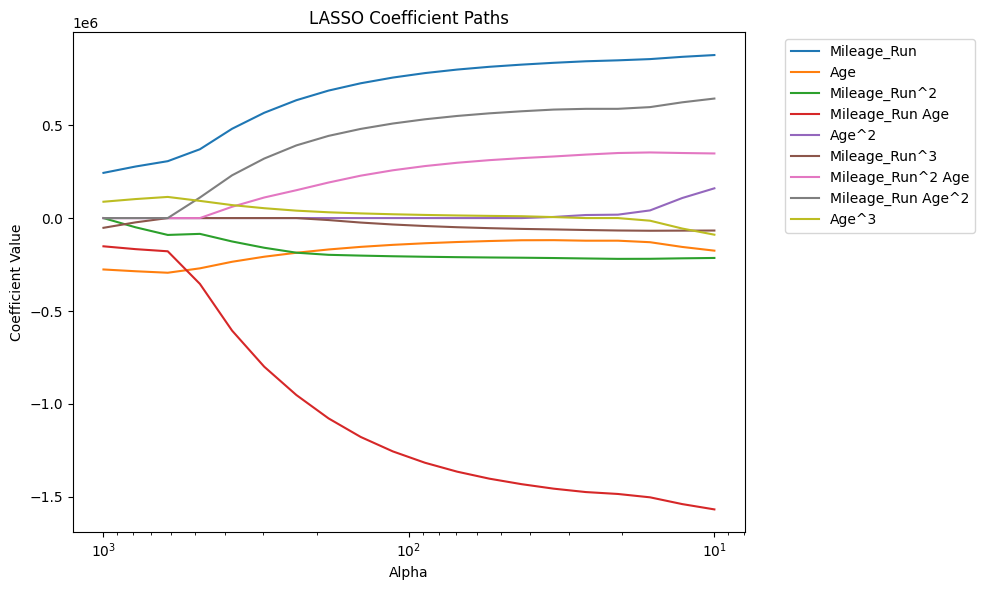

In [18]:
#Q5
from sklearn.linear_model import lasso_path
import matplotlib.pyplot as plt

alphas_lasso, coefs_lasso, _ = lasso_path(
    X_scaled,
    y,
    alphas=alphas,
    max_iter=500000
)

plt.figure(figsize=(10, 6))

for i, feature in enumerate(feature_names):
    plt.plot(alphas_lasso, coefs_lasso[i], label=feature)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.gca().invert_xaxis()
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
#Q6
lasso_coefs = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_cv.coef_
})

lasso_coefs

selected = lasso_coefs[lasso_coefs["Coefficient"] != 0]
selected

num_total = len(lasso_coefs)
num_zero = (lasso_coefs["Coefficient"] == 0).sum()
proportion_zero = num_zero / num_total

print("Total features:", num_total)
print("Zero coefficients:", num_zero)
print("Proportion zero:", proportion_zero)

Total features: 9
Zero coefficients: 1
Proportion zero: 0.1111111111111111


The LASSO model performs variable selection by shrinking some coefficients exactly to zero. In this case, out of 9 total features, 1 coefficient is set equal to zero, meaning approximately 11.1% of the features are eliminated from the model.

Q7. The LASSO model reduced the magnitude of the coefficients compared to linear regression due to the penalty term, making the model simpler and less prone to overfitting. In this case, one coefficient is shrunk to zero, meaning that feature is removed entirely. Overall, LASSO produces a more stable and interpretable model by keeping only the most important predictors.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?